# Airline Dialogue Understanding: Intent Detection & Slot Filling

This notebook implements **Spoken Language Understanding (SLU)** on the ATIS (Airline Travel Information System) benchmark dataset. Two core NLP tasks are tackled in parallel, each with a traditional machine learning baseline and a modern deep learning approach — enabling a direct four-model comparison.

---

## Environment (Google Colab)

This notebook is designed to run end-to-end in Google Colab, using a GPU runtime for the deep learning models.

**Runtime configuration:**
Runtime → Change runtime type
Hardware accelerator: GPU (T4 or better)
Python: 3.10+

---

## Dataset

The **ATIS** dataset contains transcribed airline-related dialogues, annotated for:
- **Intent** — the overall goal of the utterance (e.g., , )
- **Slots** — entity spans within the utterance (e.g., departure city, destination, date)

**Format:** Each line is a tab-separated record of `utterance`  `BIO slot labels`  `intent label`

**Splits:** , ,   
**Scale:** 18 intent classes · 130 slot labels in BIO format

---

## Models

| Task | Model | Type | Key Features |
|------|-------|------|--------------|
| Intent Detection | TF-IDF + Logistic Regression | Traditional | TF-IDF features, GridSearchCV tuning |
| Intent Detection | BERT | Modern | Fine-tuned  |
| Slot Filling | CRF | Traditional | Linguistic + domain features, BIO tagging |
| Slot Filling | BiLSTM-CRF | Modern | Bidirectional LSTM + CRF layer, PyTorch |

---


# 0. Download and import needed libraries

In [1]:
# library installs
!pip install sklearn-crfsuite
!pip install pytorch-crf

In [2]:
import os
import re
from collections import Counter, defaultdict
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from difflib import SequenceMatcher

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, make_scorer
import sklearn_crfsuite
from sklearn_crfsuite import metrics as crf_metrics

from collections import defaultdict

import torch
import torch.nn as nn
from torchcrf import CRF
from torch.utils.data import Dataset, DataLoader

from scipy.sparse import hstack

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import itertools
from operator import itemgetter

from google.colab import drive
drive.mount('/content/drive')

# Pandas display options
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Load the default templates and train dataset

## 1.1 dataloader function

In [ ]:
#!/usr/bin/env python3
"""
Data Loader Template for Slot Filling and Intent Detection

This template provides a complete framework for loading and preprocessing airline dialogue dataset.
All functions are fully implemented and ready to use.

Data format: word:slot_label word:slot_label ... <=> intent_label
Example: i:O want:O to:O fly:O from:O boston:B-fromloc.city_name to:O denver:B-toloc.city_name <=> atis_flight
"""

import os
import re
from collections import Counter, defaultdict
from typing import List, Tuple, Dict, Optional
import numpy as np

class SLUDataLoader:
    """
    Data loader for airline dialogue dataset with slot filling and intent detection tasks.
    """

    def __init__(self, data_dir: str = "../data"):
        """
        Initialize the data loader.

        Args:
            data_dir (str): Path to the data directory
        """
        self.data_dir = data_dir

        # Vocabularies and mappings
        self.word_vocab = {}  # word -> id
        self.slot_vocab = {}  # slot_label -> id
        self.intent_vocab = {} # intent -> id

        # Reverse mappings
        self.id_to_word = {}
        self.id_to_slot = {}
        self.id_to_intent = {}

        # Special tokens
        self.PAD_TOKEN = "<PAD>"
        self.UNK_TOKEN = "<UNK>"
        self.PAD_ID = 0
        self.UNK_ID = 1

        # Dataset containers
        self.train_data = None
        self.test_data = None

    def parse_line(self, line: str) -> Tuple[List[str], List[str], str]:
        """
        Parse a single line from the dataset.

        Args:
            line (str): Input line in format "word:slot word:slot ... <=> intent"

        Returns:
            Tuple[List[str], List[str], str]: (words, slot_labels, intent)

        Example:
            Input: "i:O want:O to:O fly:O <=> atis_flight"
            Output: (["i", "want", "to", "fly"], ["O", "O", "O", "O"], "atis_flight")
        """
        # Split by " <=> " first to separate input and intent
        # Then split input by spaces and extract word:slot pairs

        if " <=> " not in line:
            raise ValueError(f"Invalid line format: {line}")

        input_part, intent = line.strip().split(" <=> ")

        words = []
        slot_labels = []

        # Parse input_part to extract words and slot labels
        # Split by spaces, then split each token by ":" to get word and slot
        tokens = input_part.split()
        for token in tokens:
            if ':' in token:
                word, slot = token.split(':', 1)  # Split only on first ':'
                words.append(word)
                slot_labels.append(slot)
            else:
                # Handle cases where there might be no slot label (rare edge case)
                words.append(token)
                slot_labels.append("O")

        return words, slot_labels, intent

    def load_data_file(self, filename: str) -> List[Tuple[List[str], List[str], str]]:
        """
        Load data from a file.

        Args:
            filename (str): Name of the file to load

        Returns:
            List[Tuple[List[str], List[str], str]]: List of (words, slot_labels, intent) tuples
        """
        filepath = os.path.join(self.data_dir, filename)
        data = []

        # Read the file line by line and parse each line

        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                for line_num, line in enumerate(f, 1):
                    line = line.strip()
                    if line:  # Skip empty lines
                        try:
                            words, slots, intent = self.parse_line(line)
                            data.append((words, slots, intent))
                        except ValueError as e:
                            print(f"Error parsing line {line_num} in {filename}: {e}")
                            continue
        except FileNotFoundError:
            print(f"File not found: {filepath}")
            return []

        print(f"Loaded {len(data)} samples from {filename}")
        return data

    def build_vocabularies(self, train_data: List[Tuple[List[str], List[str], str]]) -> None:
        """
        Build vocabularies from training data.

        Args:
            train_data: List of (words, slot_labels, intent) tuples
        """
        # Collect all unique words, slot labels, and intents
        # Create mappings from strings to IDs
        # Include special tokens (PAD, UNK)

        # Initialize with special tokens
        self.word_vocab = {self.PAD_TOKEN: self.PAD_ID, self.UNK_TOKEN: self.UNK_ID}
        self.slot_vocab = {self.PAD_TOKEN: self.PAD_ID}
        self.intent_vocab = {}

        # Collect all unique tokens
        all_words = set()
        all_slots = set()
        all_intents = set()

        for words, slots, intent in train_data:
            all_words.update(words)
            all_slots.update(slots)
            all_intents.add(intent)

        # Build word vocabulary
        for i, word in enumerate(sorted(all_words), start=len(self.word_vocab)):
            self.word_vocab[word] = i

        # Build slot vocabulary
        for i, slot in enumerate(sorted(all_slots), start=len(self.slot_vocab)):
            self.slot_vocab[slot] = i

        # Build intent vocabulary
        for i, intent in enumerate(sorted(all_intents)):
            self.intent_vocab[intent] = i

        # Create reverse mappings
        self.id_to_word = {v: k for k, v in self.word_vocab.items()}
        self.id_to_slot = {v: k for k, v in self.slot_vocab.items()}
        self.id_to_intent = {v: k for k, v in self.intent_vocab.items()}

        print(f"Vocabulary sizes - Words: {len(self.word_vocab)}, "
              f"Slots: {len(self.slot_vocab)}, Intents: {len(self.intent_vocab)}")

    def words_to_ids(self, words: List[str]) -> List[int]:
        """Convert words to their corresponding IDs."""
        # Convert each word to its ID, use UNK_ID for unknown words
        return [self.word_vocab.get(word, self.UNK_ID) for word in words]

    def slots_to_ids(self, slots: List[str]) -> List[int]:
        """Convert slot labels to their corresponding IDs."""
        return [self.slot_vocab.get(slot, 0) for slot in slots]  # 0 should be PAD_ID, but slots should always exist

    def intent_to_id(self, intent: str) -> int:
        """Convert intent to its corresponding ID."""
        return self.intent_vocab.get(intent, 0)  # Intent should always exist in training

    def pad_sequences(self, sequences: List[List[int]], max_length: Optional[int] = None) -> np.ndarray:
        """
        Pad sequences to the same length.

        Args:
            sequences: List of sequences to pad
            max_length: Maximum length to pad to (if None, use longest sequence)

        Returns:
            np.ndarray: Padded sequences
        """
        if max_length is None:
            max_length = max(len(seq) for seq in sequences)

        # Pad each sequence to max_length using PAD_ID (0)
        padded = np.zeros((len(sequences), max_length), dtype=np.int32)

        for i, seq in enumerate(sequences):
            length = min(len(seq), max_length)
            padded[i, :length] = seq[:length]

        return padded

    def prepare_batch(self, data: List[Tuple[List[str], List[str], str]],
                     max_length: Optional[int] = None) -> Dict[str, np.ndarray]:
        """
        Prepare a batch of data for training/evaluation.

        Args:
            data: List of (words, slots, intent) tuples
            max_length: Maximum sequence length

        Returns:
            Dict containing:
                - 'words': padded word IDs
                - 'slots': padded slot label IDs
                - 'intents': intent IDs
                - 'lengths': actual sequence lengths (before padding)
        """
        # Convert words, slots, intents to IDs
        # Pad sequences and keep track of original lengths

        word_ids = []
        slot_ids = []
        intent_ids = []
        lengths = []

        for words, slots, intent in data:
            word_ids.append(self.words_to_ids(words))
            slot_ids.append(self.slots_to_ids(slots))
            intent_ids.append(self.intent_to_id(intent))
            lengths.append(len(words))

        # Pad sequences
        padded_words = self.pad_sequences(word_ids, max_length)
        padded_slots = self.pad_sequences(slot_ids, max_length)

        return {
            'words': padded_words,
            'slots': padded_slots,
            'intents': np.array(intent_ids),
            'lengths': np.array(lengths)
        }

    def load_unlabeled_file(self, filename: str) -> List[Tuple[List[str], List[str], str]]:
        """
        Load an unlabeled test file containing plain utterances (one per line).
        Returns tuples of (words, ['O', ...], '') with no slot or intent annotations.
        """
        filepath = os.path.join(self.data_dir, filename)
        data = []
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        words = line.split()
                        data.append((words, ['O'] * len(words), ''))
        except FileNotFoundError:
            print(f"File not found: {filepath}")
            return []
        print(f"Loaded {len(data)} samples from {filename}")
        return data

    def load_all_data(self) -> None:
        """Load training and test data."""
        print("Loading airline dialogue dataset...")

        # Load training data and build vocabularies
        self.train_data = self.load_data_file("train.txt")
        self.build_vocabularies(self.train_data)

        # Load test data — test.txt contains plain utterances without annotations
        if os.path.exists(os.path.join(self.data_dir, "test.txt")):
            self.test_data = self.load_unlabeled_file("test.txt")

        print("Dataset loading completed!")

    def get_data_stats(self) -> None:
        """Print dataset statistics."""
        if self.train_data is None:
            print("No data loaded. Call load_all_data() first.")
            return

        print("\n=== Dataset Statistics ===")
        print(f"Training samples: {len(self.train_data)}")
        print(f"Test samples: {len(self.test_data) if self.test_data else 0}")

        # Additional statistics including sequence lengths,
        # intent distribution, and slot label analysis

        # Sequence length statistics
        train_lengths = [len(words) for words, _, _ in self.train_data]
        print(f"Average sequence length: {np.mean(train_lengths):.2f}")
        print(f"Max sequence length: {max(train_lengths)}")
        print(f"Min sequence length: {min(train_lengths)}")

        # Intent distribution
        intent_counts = Counter([intent for _, _, intent in self.train_data])
        print(f"\nTop 5 intents:")
        for intent, count in intent_counts.most_common(5):
            print(f"  {intent}: {count} ({count/len(self.train_data)*100:.1f}%)")

        # Slot label distribution
        slot_counts = Counter()
        for _, slots, _ in self.train_data:
            slot_counts.update(slots)

        print(f"\nTop 10 slot labels:")
        for slot, count in slot_counts.most_common(10):
            print(f"  {slot}: {count}")

# Example usage and testing
if __name__ == "__main__":

    # Initialize data loader
    loader = SLUDataLoader(data_dir="data")

    # Load all data
    loader.load_all_data()

    # Print statistics
    loader.get_data_stats()

    # Test batch preparation
    if loader.train_data:
        sample_batch = loader.train_data[:5]  # First 5 samples
        batch = loader.prepare_batch(sample_batch)

        print(f"\n=== Sample Batch ===")
        print(f"Word IDs shape: {batch['words'].shape}")
        print(f"Slot IDs shape: {batch['slots'].shape}")
        print(f"Intent IDs shape: {batch['intents'].shape}")
        print(f"Lengths: {batch['lengths']}")

        # Show first sample conversion
        words, slots, intent = sample_batch[0]
        print(f"\nFirst sample:")
        print(f"Words: {words}")
        print(f"Slots: {slots}")
        print(f"Intent: {intent}")
        print(f"Word IDs: {batch['words'][0][:len(words)]}")
        print(f"Slot IDs: {batch['slots'][0][:len(slots)]}")
        print(f"Intent ID: {batch['intents'][0]}")

Loading airline dialogue dataset...
Loaded 4478 samples from train.txt
Vocabulary sizes - Words: 869, Slots: 121, Intents: 21
Loaded 662 samples from test.txt
Dataset loading completed!

=== Dataset Statistics ===
Training samples: 4478
Test samples: 662
Average sequence length: 11.28
Max sequence length: 46
Min sequence length: 1

Top 5 intents:
  atis_flight: 3309 (73.9%)
  atis_airfare: 385 (8.6%)
  atis_ground_service: 230 (5.1%)
  atis_airline: 139 (3.1%)
  atis_abbreviation: 130 (2.9%)

Top 10 slot labels:
  O: 32066
  B-toloc.city_name: 3919
  B-fromloc.city_name: 3892
  I-toloc.city_name: 987
  B-depart_date.day_name: 785
  B-airline_name: 639
  I-fromloc.city_name: 632
  B-depart_time.period_of_day: 521
  I-airline_name: 379
  B-depart_date.day_number: 355

=== Sample Batch ===
Word IDs shape: (5, 33)
Slot IDs shape: (5, 33)
Intent IDs shape: (5,)
Lengths: [10 33 10 19 11]

First sample:
Words: ['i', 'want', 'to', 'fly', 'from', 'baltimore', 'to', 'dallas', 'round', 'trip']
Sl

## 1.2 evaluation function

In [ ]:
"""
Evaluation Template for Slot Filling and Intent Detection

This template provides standard evaluation metrics for both tasks.
these functions can be used to evaluate their models consistently.
"""

class SLUEvaluator:
    """
    Evaluator for Spoken Language Understanding tasks:
    - Intent Detection (classification)
    - Slot Filling (sequence labeling)
    """

    def __init__(self, slot_vocab: Dict[str, int], intent_vocab: Dict[str, int]):
        """
        Initialize evaluator with vocabularies.

        Args:
            slot_vocab: Mapping from slot labels to IDs
            intent_vocab: Mapping from intent labels to IDs
        """
        self.slot_vocab = slot_vocab
        self.intent_vocab = intent_vocab

        # Reverse mappings
        self.id_to_slot = {v: k for k, v in slot_vocab.items()}
        self.id_to_intent = {v: k for k, v in intent_vocab.items()}

    def intent_accuracy(self, y_true: List[int], y_pred: List[int]) -> float:
        """
        Calculate intent detection accuracy.

        Args:
            y_true: True intent IDs
            y_pred: Predicted intent IDs

        Returns:
            float: Accuracy score
        """
        # Calculate the proportion of correctly predicted intents
        if len(y_true) != len(y_pred):
            raise ValueError("y_true and y_pred must have the same length")

        correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
        return correct / len(y_true) if len(y_true) > 0 else 0.0

    def slot_metrics(self, y_true: List[List[int]], y_pred: List[List[int]],
                    lengths: List[int]) -> Dict[str, float]:
        """
        Calculate slot filling metrics (precision, recall, F1).

        Args:
            y_true: True slot label sequences (padded)
            y_pred: Predicted slot label sequences (padded)
            lengths: Actual sequence lengths (before padding)

        Returns:
            Dict with precision, recall, f1 scores
        """
        # Remove padding based on actual lengths
        # Calculate precision, recall, F1 for slot filling
        # Handle the BIO tagging scheme properly

        all_true_slots = []
        all_pred_slots = []

        # Remove padding and flatten sequences
        for true_seq, pred_seq, length in zip(y_true, y_pred, lengths):
            # Only consider non-padded positions
            true_slots = true_seq[:length]
            pred_slots = pred_seq[:length]

            all_true_slots.extend(true_slots)
            all_pred_slots.extend(pred_slots)

        # Calculate metrics
        return self._calculate_classification_metrics(all_true_slots, all_pred_slots)

    def _calculate_classification_metrics(self, y_true: List[int], y_pred: List[int]) -> Dict[str, float]:
        """Calculate precision, recall, F1 for multi-class classification."""
        # Get unique classes (excluding padding)
        classes = set(y_true) | set(y_pred)
        if 0 in classes:  # Remove padding token
            classes.remove(0)

        true_positives = defaultdict(int)
        false_positives = defaultdict(int)
        false_negatives = defaultdict(int)

        # For each class, count TP, FP, FN
        for true_label, pred_label in zip(y_true, y_pred):
            if true_label == 0 and pred_label == 0:  # Skip padding
                continue

            if true_label == pred_label and true_label != 0:
                true_positives[true_label] += 1
            else:
                if pred_label != 0:
                    false_positives[pred_label] += 1
                if true_label != 0:
                    false_negatives[true_label] += 1

        # Calculate macro averages
        precisions = []
        recalls = []
        f1s = []

        for class_id in classes:
            tp = true_positives[class_id]
            fp = false_positives[class_id]
            fn = false_negatives[class_id]

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

            precisions.append(precision)
            recalls.append(recall)
            f1s.append(f1)

        return {
            'precision': np.mean(precisions) if precisions else 0.0,
            'recall': np.mean(recalls) if recalls else 0.0,
            'f1': np.mean(f1s) if f1s else 0.0
        }

    def entity_level_f1(self, y_true: List[List[int]], y_pred: List[List[int]],
                       lengths: List[int]) -> float:
        """
        Calculate entity-level F1 score (stricter evaluation).
        An entity is correct only if both boundaries and type are correct.

        Args:
            y_true: True slot label sequences
            y_pred: Predicted slot label sequences
            lengths: Actual sequence lengths

        Returns:
            float: Entity-level F1 score
        """
        # Extract entities from BIO tags and compare complete entities
        # rather than individual tokens (stricter evaluation)

        def extract_entities(labels, length):
            """Extract entities from BIO-tagged sequence."""
            entities = []
            current_entity = None

            for i in range(length):
                label = self.id_to_slot.get(labels[i], 'O')

                if label.startswith('B-'):
                    # Start of new entity
                    if current_entity:
                        entities.append(current_entity)
                    current_entity = {'type': label[2:], 'start': i, 'end': i}
                elif label.startswith('I-') and current_entity:
                    # Continue current entity
                    if label[2:] == current_entity['type']:
                        current_entity['end'] = i
                    else:
                        # Type mismatch, end current entity
                        entities.append(current_entity)
                        current_entity = None
                else:
                    # O label or invalid I- tag
                    if current_entity:
                        entities.append(current_entity)
                        current_entity = None

            # Add last entity if exists
            if current_entity:
                entities.append(current_entity)

            return {(e['start'], e['end'], e['type']) for e in entities}

        all_true_entities = set()
        all_pred_entities = set()

        for true_seq, pred_seq, length in zip(y_true, y_pred, lengths):
            true_entities = extract_entities(true_seq, length)
            pred_entities = extract_entities(pred_seq, length)

            all_true_entities.update(true_entities)
            all_pred_entities.update(pred_entities)

        # Calculate entity-level metrics
        tp = len(all_true_entities & all_pred_entities)
        fp = len(all_pred_entities - all_true_entities)
        fn = len(all_true_entities - all_pred_entities)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        return f1

    def detailed_intent_report(self, y_true: List[int], y_pred: List[int]) -> Dict:
        """Generate detailed classification report for intents."""
        from sklearn.metrics import classification_report, confusion_matrix

        # Use sklearn's classification_report for detailed per-class metrics

        # Get intent names
        target_names = [self.id_to_intent[i] for i in sorted(self.intent_vocab.values())]

        report = classification_report(y_true, y_pred,
                                     target_names=target_names,
                                     output_dict=True,
                                     zero_division=0)

        return report

    def plot_confusion_matrix(self, y_true: List[int], y_pred: List[int],
                             title: str = "Intent Confusion Matrix"):
        """Plot confusion matrix for intent detection."""
        from sklearn.metrics import confusion_matrix

        # Create and plot confusion matrix using seaborn

        # Get intent names for labels
        intent_names = [self.id_to_intent[i] for i in sorted(self.intent_vocab.values())]

        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d',
                   xticklabels=intent_names,
                   yticklabels=intent_names,
                   cmap='Blues')
        plt.title(title)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        return plt.gcf()

    def evaluate_model(self, y_true_intents: List[int], y_pred_intents: List[int],
                      y_true_slots: List[List[int]], y_pred_slots: List[List[int]],
                      lengths: List[int], verbose: bool = True) -> Dict:
        """
        Complete evaluation of both intent detection and slot filling.

        Returns:
            Dict: Complete evaluation results
        """
        results = {}

        # Intent detection metrics
        intent_acc = self.intent_accuracy(y_true_intents, y_pred_intents)
        results['intent_accuracy'] = intent_acc

        # Slot filling metrics
        slot_metrics = self.slot_metrics(y_true_slots, y_pred_slots, lengths)
        results.update({f'slot_{k}': v for k, v in slot_metrics.items()})

        # Entity-level F1
        entity_f1 = self.entity_level_f1(y_true_slots, y_pred_slots, lengths)
        results['entity_f1'] = entity_f1

        if verbose:
            print("=== Evaluation Results ===")
            print(f"Intent Accuracy: {intent_acc:.4f}")
            print(f"Slot Precision:  {slot_metrics['precision']:.4f}")
            print(f"Slot Recall:     {slot_metrics['recall']:.4f}")
            print(f"Slot F1:         {slot_metrics['f1']:.4f}")
            print(f"Entity F1:       {entity_f1:.4f}")

        return results

# Example usage
if __name__ == "__main__":
    # Example usage with dummy data for testing

    # Dummy vocabularies for testing
    slot_vocab = {"<PAD>": 0, "O": 1, "B-fromloc.city_name": 2, "I-fromloc.city_name": 3}
    intent_vocab = {"atis_flight": 0, "atis_airfare": 1}

    evaluator = SLUEvaluator(slot_vocab, intent_vocab)

    # Dummy predictions for testing
    y_true_intents = [0, 1, 0, 1]
    y_pred_intents = [0, 1, 1, 1]  # One wrong prediction

    y_true_slots = [[1, 1, 2, 3, 0], [1, 2, 1, 0, 0]]
    y_pred_slots = [[1, 1, 2, 3, 0], [1, 2, 2, 0, 0]]  # One wrong prediction
    lengths = [4, 3]

    # Test evaluation
    results = evaluator.evaluate_model(
        y_true_intents, y_pred_intents,
        y_true_slots, y_pred_slots,
        lengths, verbose=True
    )

    print(f"\nComplete results: {results}")

=== Evaluation Results ===
Intent Accuracy: 0.7500
Slot Precision:  0.8889
Slot Recall:     0.9167
Slot F1:         0.8857
Entity F1:       0.8000

Complete results: {'intent_accuracy': 0.75, 'slot_precision': np.float64(0.8888888888888888), 'slot_recall': np.float64(0.9166666666666666), 'slot_f1': np.float64(0.8857142857142857), 'entity_f1': 0.8}


# 2. EDA

## 2.1 Dataset statistics & overview

#### 2.1.1 basic descriptive statistics

By using the function defined by the templates, we can see the descriptive statistics like the number of samples is correct and the average, min and max length with 11.28, 1, 46, hwile the top 5 intents show that the most of intent are atis_flight with 73.9%

In [5]:
loader.get_data_stats()


=== Dataset Statistics ===
Training samples: 4478
Validation samples: 0
Test samples: 0
Average sequence length: 11.28
Max sequence length: 46
Min sequence length: 1

Top 5 intents:
  atis_flight: 3309 (73.9%)
  atis_airfare: 385 (8.6%)
  atis_ground_service: 230 (5.1%)
  atis_airline: 139 (3.1%)
  atis_abbreviation: 130 (2.9%)

Top 10 slot labels:
  O: 32066
  B-toloc.city_name: 3919
  B-fromloc.city_name: 3892
  I-toloc.city_name: 987
  B-depart_date.day_name: 785
  B-airline_name: 639
  I-fromloc.city_name: 632
  B-depart_time.period_of_day: 521
  I-airline_name: 379
  B-depart_date.day_number: 355


### 2.1.2 train / validation split

* In this section, we identified all singleton intents (frequency = 1) and kept them entirely in the training set to avoid error with the minimum-class constraint during stratified splitting. This approach maintained representativeness while ensuring that no unseen intents appeared in the validation set. We then applied an 80/20 stratified split to the remaining samples, merged the two parts into the final training set, and used a fixed random seed for reproducibility. Finally, we verified the post-split intent distributions to confirm alignment with the original dataset.

In [6]:
data = loader.train_data
idx = np.arange(len(data))
intents = np.array([it for _,_,it in data])

# identify intents that appear only once
cnt = Counter(intents)
singleton_labels = {lab for lab, c in cnt.items() if c == 1}
singleton_mask = np.array([it in singleton_labels for it in intents])
idx_singleton = idx[singleton_mask]
idx_rest      = idx[~singleton_mask]
intents_rest  = intents[~singleton_mask]

# split the data by 80/20
train_idx_rest, val_idx_rest = train_test_split(
    idx_rest, test_size=0.2, random_state=123, stratify=intents_rest
)

# merge the final split and randomly scatter the training index
train_idx = np.concatenate([train_idx_rest, idx_singleton])
val_idx   = val_idx_rest

rng = np.random.default_rng(123)
rng.shuffle(train_idx)

# get data
train_split = [data[i] for i in train_idx]
val_split   = [data[i] for i in val_idx]

print(f"Train: {len(train_split)} | Validation: {len(val_split)}")
print(f"count of sentence with 1 intent ：{len(singleton_labels)}")

# check the result
def show_dist(tag, ds):
    c = Counter([it for _,_,it in ds])
    df = pd.DataFrame(sorted(c.items(), key=lambda x: -x[1]), columns=["intent","count"])
    df["ratio_%"] = (df["count"] / len(ds) * 100).round(2)
    print(tag, f"(N={len(ds)})"); display(df.head(10))

show_dist("TRAIN", train_split)
show_dist("VAL", val_split)

Train: 3583 | Validation: 895
count of sentence with 1 intent ：3
TRAIN (N=3583)


,intent,count,ratio_%
0,atis_flight,2647,73.88
1,atis_airfare,308,8.60
2,atis_ground_service,184,5.14
3,atis_airline,111,3.10
4,atis_abbreviation,104,2.90
5,atis_aircraft,56,1.56
6,atis_flight_time,36,1.00
7,atis_quantity,33,0.92
8,atis_flight;atis_airfare,15,0.42
9,atis_distance,14,0.39


VAL (N=895)


,intent,count,ratio_%
0,atis_flight,662,73.97
1,atis_airfare,77,8.60
2,atis_ground_service,46,5.14
3,atis_airline,28,3.13
4,atis_abbreviation,26,2.91
5,atis_aircraft,14,1.56
6,atis_flight_time,9,1.01
7,atis_quantity,8,0.89
8,atis_flight;atis_airfare,4,0.45
9,atis_city,4,0.45


### 2.1.3 slot distribution

* By visualizing the distribution of number of slot for each utterance. We can observe that the majority of utterances contain between 2 and 4 slots, usually representing origin and destination cities along with optional time or date expressions. This distribution also indicates that most of the sentences in this dataset are moderately complex queries instead of generic queries like "what is atis" or complex multiple requests contain city, date and airline.

* Futhermore, we also create a bar chart to see the top20 frequent slot label to help us understand the labels and also create the features in the next steps. We can observe that the distribution is highly skewed, most of the labels are O and beginning of city name.

/tmp/ipython-input-3132258464.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(cats, sort=False).plot(kind="bar")


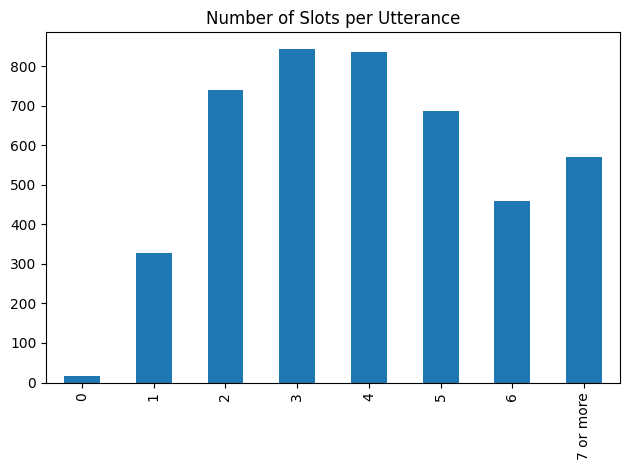

In [7]:
# count for each utterance
slots_per_utt = [sum(1 for s in slots if s!="O") for _,slots,_ in loader.train_data]
cats = pd.cut(slots_per_utt, bins=[0,1,2,3,4,5,6,7,9999], labels=["0","1","2","3","4","5","6","7 or more"], right=False)
pd.value_counts(cats, sort=False).plot(kind="bar")
# visualization
plt.title("Number of Slots per Utterance")
plt.tight_layout(); plt.show()

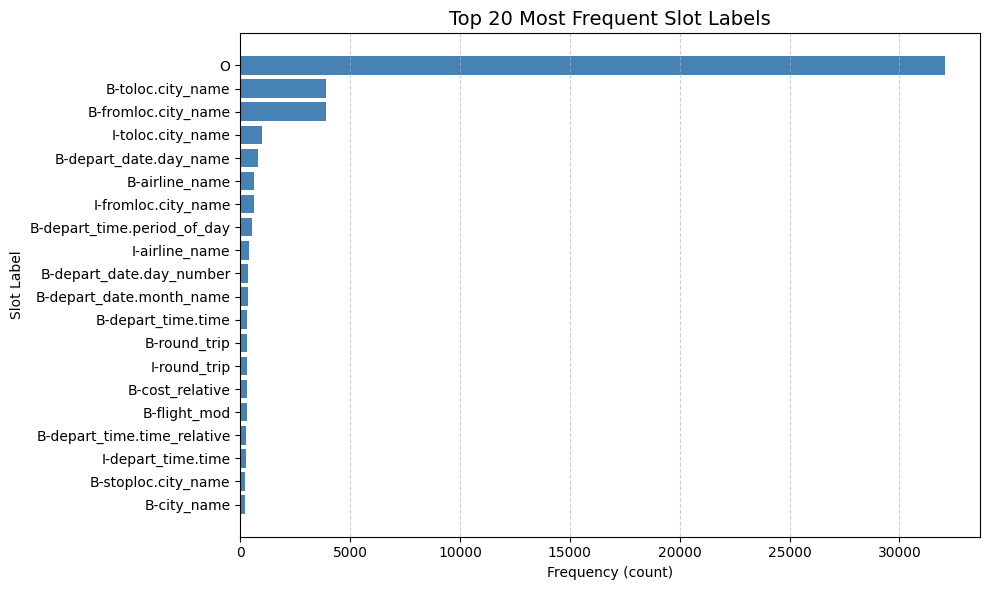

In [8]:
# count slots
slot_counts = Counter()
for _, slots, _ in loader.train_data:
    slot_counts.update(slots)

# get plot
top_n = 20
df_slots = pd.DataFrame(slot_counts.most_common(top_n), columns=["Slot", "Count"])

# visualization
plt.figure(figsize=(10,6))
plt.barh(df_slots["Slot"], df_slots["Count"], color="steelblue")
plt.gca().invert_yaxis()
plt.title(f"Top {top_n} Most Frequent Slot Labels", fontsize=14)
plt.xlabel("Frequency (count)")
plt.ylabel("Slot Label")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### 2.1.4 sequence length analysis

By visualizing the histogram, we can see the distribution of utterance, the majority of utterances contain between 8 and 15 tokens and the distribution is right-skewed, indicating that most user queries are short and concise, while a small number of longer utterances likely represent complex or multi-slot queries.

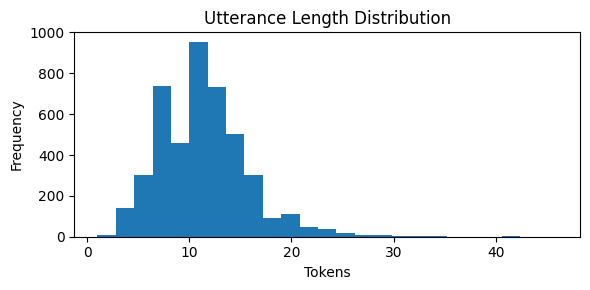

In [9]:
# histogram to show length of utterance
lens = [len(w) for w,_,_ in loader.train_data]
plt.figure(figsize=(6,3))
pd.Series(lens).plot(kind="hist", bins=25)
plt.title("Utterance Length Distribution"); plt.xlabel("Tokens"); plt.tight_layout(); plt.show()

### 2.1.5 outliers checking

I create the boxplot to visualize the outliers clearly. We can observe several utterances, particularly within the atis_flight intent, exhibit unusually long lengths.

By see the top 5 longest utterances, we can see that these correspond to complex queries, Such cases are not annotation errors but linguistically valid examples that increase the dataset’s variability.

Therefore, these outliers were retained to preserve natural data diversity, though their presence may slightly increase model variance during training.

<Figure size 1000x400 with 0 Axes>

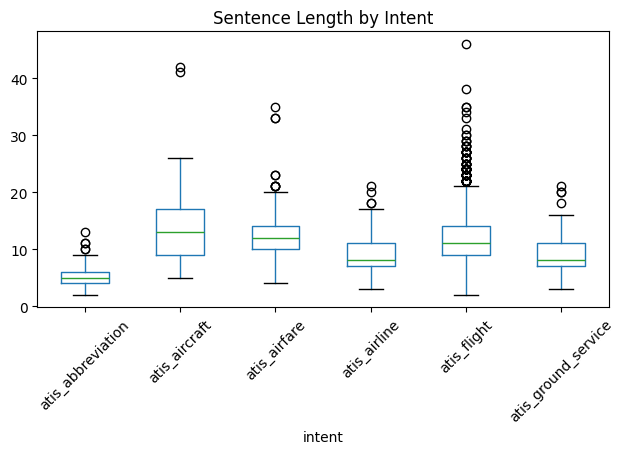

In [10]:
# boxplot to visualize the outliers by intent
rows = [{"intent":it, "len":len(w)} for w,_,it in loader.train_data]
df_len = pd.DataFrame(rows)
intent_counts = Counter(i for _,_,i in loader.train_data)
top_intents = [x for x,_ in intent_counts.most_common(6)]
plt.figure(figsize=(10,4))
df_len[df_len["intent"].isin(top_intents)].boxplot(by="intent", column="len", grid=False, rot=45)
plt.suptitle(""); plt.title("Sentence Length by Intent"); plt.tight_layout(); plt.show()

In [11]:
# check the top5 longest utterance
print("Top 5 longest utterances:")
for i in np.argsort(lens)[-5:][::-1]:
    w,_,it = loader.train_data[i]
    print(f"len={len(w)} | intent={it} | text={' '.join(w)}")

Top 5 longest utterances:
len=46 | intent=atis_flight | text=i want to travel from kansas city to chicago round trip leaving wednesday june sixteenth arriving in chicago at around 7 o'clock in the evening and returning the next day arriving in kansas city at around 7 o'clock in the evening which airlines fly that route
len=42 | intent=atis_aircraft | text=all right would you let me know type of aircraft united airlines is using on the flights from denver to san francisco i would like to know the type of aircraft that they use on these flights before 10 in the morning
len=41 | intent=atis_aircraft | text=i'm going to leave philadelphia and i want to go to san francisco and i want to fly first class american and i want a stop in dallas can you please tell me what type of aircraft you will be flying
len=38 | intent=atis_flight | text=i would like to find a flight from kansas city to salt lake city on delta and arriving at about 8 o'clock in the evening could you please tell me the aircraf

In [12]:
# check the top5 shortest utterance
print("Top 5 shortest utterances:")
for i in np.argsort(lens)[:5]:
    w,_,it = loader.train_data[i]
    print(f"len={len(w)} | intent={it} | text={' '.join(w)}")

Top 5 shortest utterances:
len=1 | intent=atis_airport | text=airports
len=2 | intent=atis_airport | text=houston airports
len=2 | intent=atis_airport | text=houston airports
len=2 | intent=atis_abbreviation | text=code ff
len=2 | intent=atis_flight | text=us 201


## 2.2 Data quality & consistency analysis

### 2.2.1 Label Consistency

In this section, we group and compare sentences with identical text across their assigned intent and slot labels to evaluate annotation consistency

Since there is only one conflict, I decide to keep them to reflect ambiguous or multi-interpretation queries rather than annotation errors.

In [13]:
# create dataframe
texts = [" ".join(w) for w,_,_ in loader.train_data]
df_train = pd.DataFrame({
    "text": texts,
    "intent": [i for _,_,i in loader.train_data],
    "slots_str": [" ".join(s) for _,s,_ in loader.train_data]
})

# find the exactly same sentence
conflicts = []
for txt, g in df_train.groupby("text"):
    if len(g) > 1:
        if len(set(g["intent"])) > 1 or len(set(g["slots_str"])) > 1:
            conflicts.append((txt, g[["intent","slots_str"]].drop_duplicates()))
# check the result
print(f"similar phrases have different labels：{len(conflicts)}")
for i,(txt,g) in enumerate(conflicts[:5],1):
    print(f"\n[conflict {i}] text= {txt}")
    display(g)

similar phrases have different labels：1

[conflict 1] text= which flights are between boston and baltimore washington


,intent,slots_str
2065,atis_flight,O O O O B-fromloc.city_name O B-toloc.city_name B-toloc.city_name
3753,atis_flight,O O O O B-fromloc.city_name O B-toloc.city_name B-toloc.state_name


To evaluate linguistic diversity and potential redundancy, a near-duplicate analysis was performed using SequenceMatcher with a similarity threshold of 0.9.

For each pair of utterances with ≥90% character-level similarity, the pair was flagged as a near duplicate.
Among the first 500 samples, 13 pairs of near-duplicate sentences were identified.

These near-duplicates typically reflect realistic repetition patterns in user queries rather than data noise. Therefore, they were retained as they provide examples of natural paraphrasing.



In [14]:
# compare the similar sentences
def near_duplicates(dataset, threshold=0.9):
    near = []
    texts = [" ".join(w) for w,_,_ in dataset]
    for i in range(len(texts)):
        for j in range(i+1, len(texts)):
            sim = SequenceMatcher(None, texts[i], texts[j]).ratio()
            if sim >= threshold and texts[i]!=texts[j]:
                near.append((i,j,sim))
    return near
# show the numbers of similar sentences for first 500 records
near_pairs = near_duplicates(loader.train_data[:500], 0.9)
print(f"90% similarity sentences in the first 500 records：{len(near_pairs)}")

90% similarity sentences in the first 500 records：13


### 2.2.2 BIO Tagging Validation

* After checking, there is no wrong tag with BIO, all of them strictly follow the rule.

In [15]:
def bio_errors(words, slots):
    errs = []
    prev_tag, prev_type = "O", None
    for i, tag in enumerate(slots):
        if tag == "O":
            prev_tag, prev_type = "O", None
            continue
        parts = tag.split("-", 1)
        bio = parts[0]; typ = parts[1] if len(parts)==2 else None
        if bio == "I":
            if prev_tag not in {"B","I"} or typ != prev_type:
                errs.append((i, words[i], tag))
        prev_tag, prev_type = bio, typ
    return errs

bio_bad = []
for w,s,it in loader.train_data:
    e = bio_errors(w,s)
    if e: bio_bad.append((w,s,it,e))

print(f"sentences with wrong BIO：{len(bio_bad)} / {len(loader.train_data)}")
if bio_bad[:3]:
    print("\n 3 examples：")
    for w,s,it,e in bio_bad[:3]:
        print("text =", " ".join(w))
        print("slots=", " ".join(s))
        print("intent=", it)
        print("errors=", e)
        print("---")

sentences with wrong BIO：0 / 4478


### 2.2.3 Missing Data

* Also no missing data in the dataset

In [16]:
file_path = os.path.join(loader.data_dir, "train.txt")
with open(file_path, "r", encoding="utf-8") as f:
    lines = [l.strip() for l in f]

empty_lines = [i for i,l in enumerate(lines) if l==""]

malformed = []
for i,l in enumerate(lines):
    if " <=> " not in l:
        malformed.append(i)

print(f"empty：{len(empty_lines)} | malformed：{len(malformed)}")

if malformed:
    for idx in malformed[:3]:
        print(idx, lines[idx])

empty：0 | malformed：0


### 2.2.4 Duplicate / Near-Duplicate Analysis

There are some duplicated data sentences in the dataset, but we didn't remove it because that might help model to learn some patterns for different intents.

In [17]:
duplicated = df_train[df_train.duplicated(subset=["text"], keep=False)]
print(f"Duplicate sentences：{len(duplicated)}")
display(duplicated.head(10))

Duplicate sentences：509


,text,intent,slots_str
1,round trip fares from baltimore to philadelphia less than 1000 dollars round trip fares from denver to philadelphia less than 1000 dollars round trip fares from pittsburgh to philadelphia less than 1000 dollars,atis_airfare,B-round_trip I-round_trip O O B-fromloc.city_name O B-toloc.city_name B-cost_relative O B-fare_amount I-fare_amount B-round_trip I-round_trip O O B-fromloc.city_name O B-toloc.city_name B-cost_relative O B-fare_amount I-fare_amount B-round_trip I-round_trip O O B-fromloc.city_name O B-toloc.city_name B-cost_relative O B-fare_amount I-fare_amount
4,which airlines fly from boston to washington dc via other cities,atis_airline,O O O O B-fromloc.city_name O B-toloc.city_name B-toloc.state_code O O O
25,from seattle to salt lake city,atis_flight,O B-fromloc.city_name O B-toloc.city_name I-toloc.city_name I-toloc.city_name
31,what does fare code y mean,atis_abbreviation,O O O O B-fare_basis_code O
40,show me the flights from dallas to atlanta,atis_flight,O O O O O B-fromloc.city_name O B-toloc.city_name
48,what does fare code qx mean,atis_abbreviation,O O O O B-fare_basis_code O
67,show me the nonstop flights from dallas to houston,atis_flight,O O O B-flight_stop O O B-fromloc.city_name O B-toloc.city_name
71,what is ewr,atis_abbreviation,O O B-airport_code
78,i'd like to go from boston to san francisco,atis_flight,O O O O O B-fromloc.city_name O B-toloc.city_name I-toloc.city_name
81,what is mco,atis_abbreviation,O O B-airport_code


## 2.3 Linguistic & Senmatic analysis

#### 2.3.1 Out-of-vocabulary (OOV) analysis

* By OOV analysis, we can see that there are about 11% of the validation words are unseen during training in this dataset. Therefore, when feature engineering, we include general and pattern-based features like digit flag to help model generalize to unseen words instead of memorizing only training vocabulary.

In [18]:
# find the words that in the validation while not in the training dataset
train_vocab = set(w.lower() for w,_,_ in train_split for w in w)
val_vocab = set(w.lower() for w,_,_ in val_split for w in w)
oov_words = val_vocab - train_vocab
print(f"out of vocabulary in validation: {len(oov_words)} ({len(oov_words)/len(val_vocab)*100:.2f}%)")
print("Examples:", list(oov_words)[:20])

out of vocabulary in validation: 64 (11.72%)
Examples: ['823', 'provides', '305', 'scheduled', 'trans', '402', '1505', 'including', '1300', 'hartfield', 'across', '459', 'takeoff', '0900', 'locate', 'runs', 'four', 'begins', '1130', '500']


### 2.3.2 frequent vocabulary

* The plot shows that common function words such as to, from, flights, and the dominate the vocabulary. These high-frequency words mostly represent prepositions and general tokens that appear across many utterances, while content-specific words (e.g., boston, denver, pittsburgh) appear less frequently.

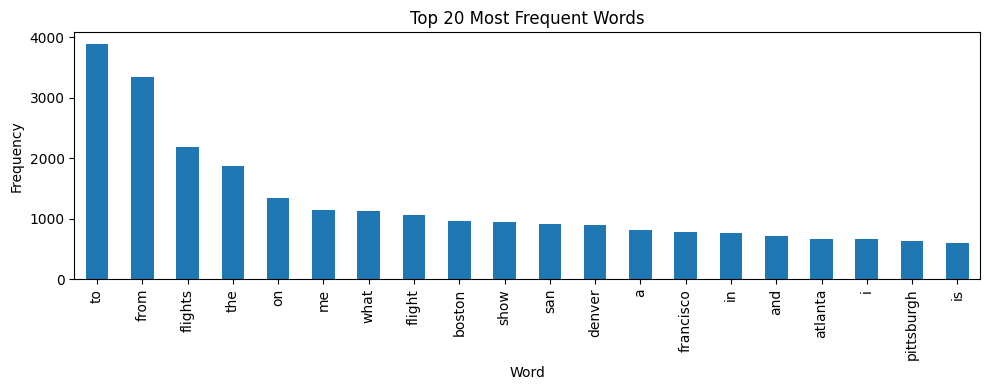

In [19]:
# find the most frequent words
all_words = [w.lower() for sent,_,_ in loader.train_data for w in sent]
word_freq = Counter(all_words)
pd.Series(word_freq).sort_values(ascending=False).head(20).plot(kind="bar", figsize=(10,4))
plt.title("Top 20 Most Frequent Words"); plt.xlabel("Word"); plt.ylabel("Frequency"); plt.tight_layout(); plt.show()

### 2.3.3 Slot Transition Patterns for top 20 slots

* This visualization shows the transition matrix among the 20 most frequent slot labels.
The darkest cells correspond to transitions such as O to O, B-fromloc.city_name to I-fromloc.city_name, and B-toloc.city_name to I-toloc.city_name, indicating that consistent BIO tagging behavior.
Most other transitions have near-zero frequency, which means that entities rarely overlap.

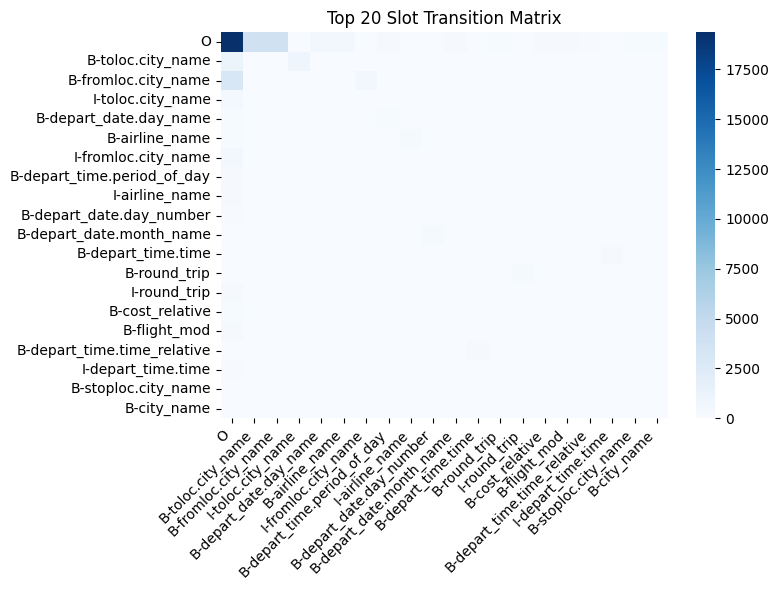

In [20]:
# get the top 20 slots
slot_counts = Counter(s for _,slots,_ in loader.train_data for s in slots)
top_slots = [s for s,_ in slot_counts.most_common(20)]

# create the transition matrix for top 20 slots
tag2id = {t:i for i,t in enumerate(top_slots)}
M = np.zeros((len(top_slots), len(top_slots)), dtype=int)
for _,slots,_ in loader.train_data:
    for a,b in zip(slots[:-1], slots[1:]):
        if a in tag2id and b in tag2id:
            M[tag2id[a], tag2id[b]] += 1

plt.figure(figsize=(8,6))
sns.heatmap(M, cmap="Blues", xticklabels=top_slots, yticklabels=top_slots)
plt.title("Top 20 Slot Transition Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### 2.3.4 Intent-Specific Patterns

We create wordcloud to see the most common words for the top 5 common intents. We can use it to generate the keyword dictionary for the top 5 common intents to help model identify them by this wordcloud

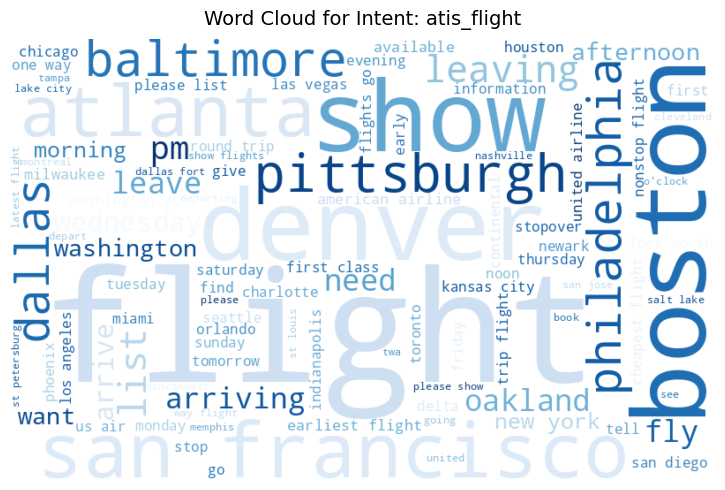

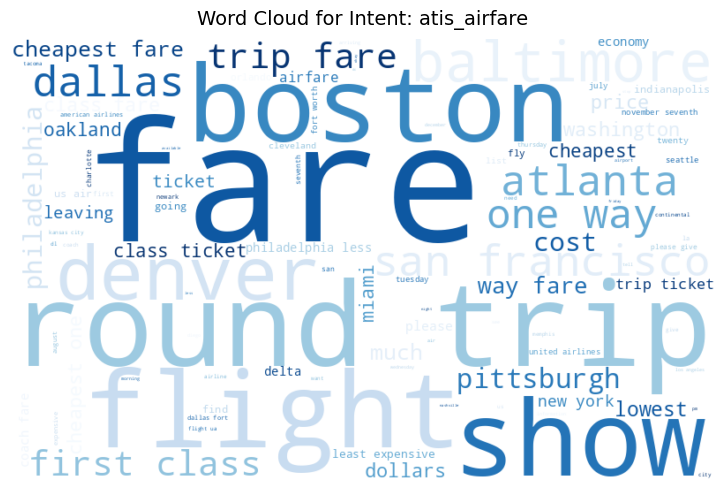

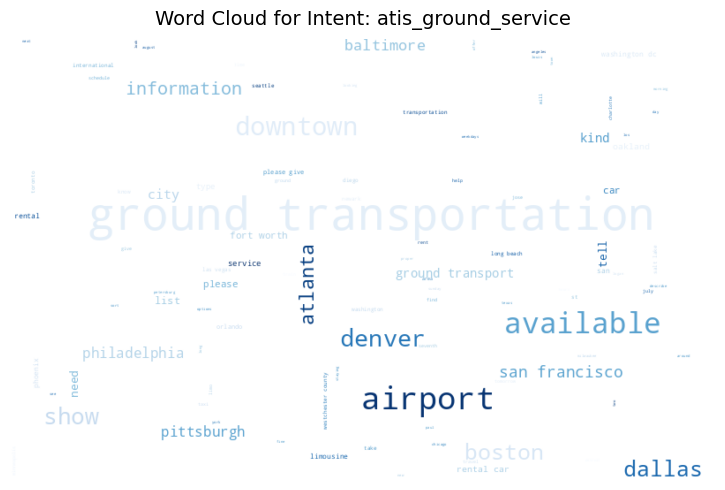

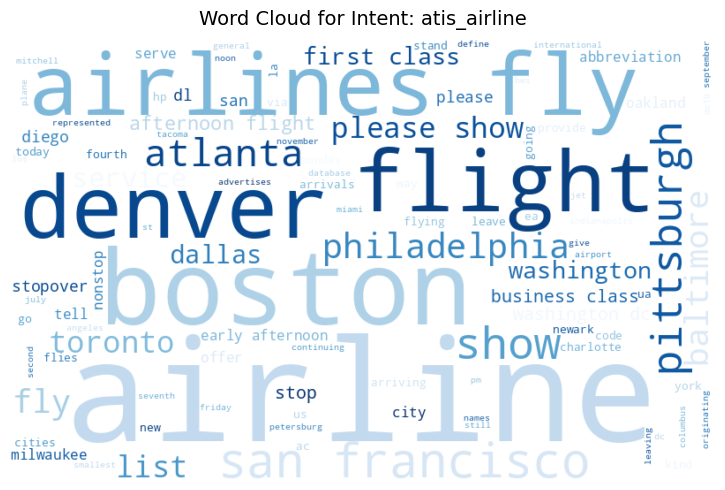

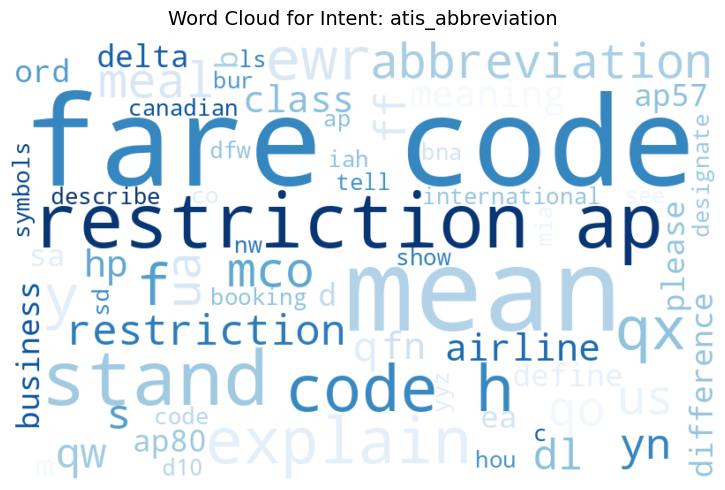

In [21]:
from wordcloud import WordCloud
# create word clouds for top5 most common intents.
# get the top 6 intents
intent_counts = Counter(it for _,_,it in loader.train_data)
top_intents = [it for it,_ in intent_counts.most_common(5)]

# generate the word cloud for each top5 intent
for intent in top_intents:
    # collect the words
    words = [word.lower() for w,_,it in loader.train_data if it == intent for word in w]
    text = " ".join(words)

    # create cloud
    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        colormap="Blues",
        max_words=100
    ).generate(text)

    # visualize
    plt.figure(figsize=(8,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for Intent: {intent}", fontsize=14, pad=10)
    plt.tight_layout()
    plt.show()

# 3. Build the Models

* we use CRF as traditional model and BiLSTM-CRF as the modern model for slot filling, TF-IDF + Logistic Regression as traditional model and BERT as the modern model for intent detection

## 3.1 Fill slots

### 3.1.1 Feature engineering

* We design these feartures from what we observed from EDA.
1. Domain Gazetteer Features(in_city, in_airline, in_dayname, in_daynum, in_monthname, in_period, in_time, in_time_relative, in_round_trip, in_cost_relative, in_flight_mod.): Slot distribution plots showed that the most frequent slot types, we use it to construct the domain lexicons automatically from the training data.
2. word.lower: normalized word form to reduce sparsity.

3. is_title, is_upper: capture capitalization patterns linked to named entities.

4. is_digit: detects numeric slots.

5. pref3, suf3: extract morphological hints like weekday or day.

6. len_bin_<=8, len_bin_9to15, len_bin_>15: derived from Sequence-length analysis. We might can use sentence length bins to represent utterance complexity.

7. pos_B, pos_E: indicate whether the token is at the beginning or end of the sentence.

8. BOS, EOS: explicit boundary markers.

9. ±1/±2:w.lower, ±1/±2:is_title: to see patterns between sentence contexts.

10. after_from, after_to, before_to: to and from are almost two most frequent word in this dataset, and it particularly connected to the phrases from A to B.Therefore, we create them as syntactic cues for prepositional structures.

* In summary, these features encode both linguistic regularities and domain-specific semantics, enabling the CRF to learn accurate emission and transition probabilities for BIO slot tagging.

In [22]:
def build_lexicons(train_data):
    lex = defaultdict(set)

    # collect B/I
    for words, slots, _ in train_data:
        for w, s in zip(words, slots):
            if s.startswith('B-') or s.startswith('I-'):
                typ = s.split('-', 1)[1]  # e.g., toloc.city_name
                lex[typ].add(w)

    # aggregation
    # city
    city = (
        lex.get('fromloc.city_name', set()) |
        lex.get('toloc.city_name', set())   |
        lex.get('stoploc.city_name', set())
    )
    # airline
    airline = lex.get('airline_name', set())

    # date
    dayname = (
        lex.get('depart_date.day_name', set()) |
        lex.get('arrive_date.day_name', set())
    )
    daynum = (
        lex.get('depart_date.day_number', set()) |
        lex.get('arrive_date.day_number', set())
    )
    monthname = (
        lex.get('depart_date.month_name', set()) |
        lex.get('arrive_date.month_name', set())
    )

    # time
    period = (
        lex.get('depart_time.period_of_day', set()) |
        lex.get('arrive_time.period_of_day', set())
    )
    time_exact = (
        lex.get('depart_time.time', set()) |
        lex.get('arrive_time.time', set())
    )
    time_relative = (
        lex.get('depart_time.time_relative', set()) |
        lex.get('arrive_time.time_relative', set())
    )

    # other high frequency
    round_trip = (
        lex.get('round_trip', set())
    )
    cost_relative = (
        lex.get('cost_relative', set())
    )
    flight_mod = (
        lex.get('flight_mod', set())
    )

    # lower and return
    tolower = lambda s: {w.lower() for w in s}
    return {
        'city':          tolower(city),
        'airline':       tolower(airline),
        'dayname':       tolower(dayname),
        'daynum':        tolower(daynum),
        'monthname':     tolower(monthname),
        'period':        tolower(period),
        'time':          tolower(time_exact),
        'time_relative': tolower(time_relative),
        'round_trip':    tolower(round_trip),
        'cost_relative': tolower(cost_relative),
        'flight_mod':    tolower(flight_mod),
    }

# create
lexicons = build_lexicons(train_split)


In [23]:
def boolint(x): return int(bool(x))

def word2features(sent, i):
    w_orig = sent[i]
    w = w_orig.lower()
    feats = {
        'word.lower': w,
        'is_title': w_orig.istitle(),
        'is_upper': w_orig.isupper(),
        'is_digit': w_orig.isdigit(),
        'pref3': w[:3],
        'suf3': w[-3:],
        'in_city':          int(w in lexicons['city']),
        'in_airline':       int(w in lexicons['airline']),
        'in_dayname':       int(w in lexicons['dayname']),
        'in_daynum':        int(w in lexicons['daynum']),
        'in_monthname':     int(w in lexicons['monthname']),
        'in_period':        int(w in lexicons['period']),
        'in_time':          int(w in lexicons['time']),
        'in_time_relative': int(w in lexicons['time_relative']),
        'in_round_trip':    int(w in lexicons['round_trip']),
        'in_cost_relative': int(w in lexicons['cost_relative']),
        'in_flight_mod':    int(w in lexicons['flight_mod']),
    }
    L = len(sent)
    feats.update({
        'len_bin_<=8':  boolint(L <= 8),
        'len_bin_9to15': boolint(9 <= L <= 15),
        'len_bin_>15':  boolint(L > 15),
        'pos_B':        boolint(i == 0),
        'pos_E':        boolint(i == L-1),
    })
    for off in (-2,-1,1,2):
        j = i + off
        if 0 <= j < L:
            jw = sent[j]; jlw = jw.lower()
            feats.update({f'{off}:w.lower': jlw, f'{off}:is_title': boolint(jw.istitle())})
    feats['after_from'] = boolint(i>0   and sent[i-1].lower()=='from')
    feats['after_to']   = boolint(i>0   and sent[i-1].lower()=='to')
    feats['before_to']  = boolint(i<L-1 and sent[i+1].lower()=='to')
    if i == 0:    feats['BOS'] = True
    if i == L-1:  feats['EOS'] = True
    return feats

### 3.1.2 traditional technique model: CRF model

In [24]:
# apply features to the dataset
def sent2features(words): return [word2features(words, i) for i in range(len(words))]
def sent2labels(slots):   return slots

X_train = [sent2features(w) for w,_,_ in train_split]
y_train = [s for _,s,_ in train_split]
X_val   = [sent2features(w) for w,_,_ in val_split]
y_val   = [s for _,s,_ in val_split]

# baseline model
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1, c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)
# apply to dataset
crf.fit(X_train, y_train)

CRF(algorithm='lbfgs', all_possible_transitions=True, c1=0.1, c2=0.1,
    max_iterations=100)

In [25]:
# get prediction in validation file
y_pred_slots_crf = crf.predict(X_val)
labels = [lab for lab in loader.slot_vocab.keys() if lab not in {'O', '<PAD>'}]
f1 = crf_metrics.flat_f1_score(y_val, y_pred_slots_crf, average='macro', labels=labels)

# check the performance
print(f"CRF Validation macro-F1 = {f1:.4f}")

CRF Validation macro-F1 = 0.6270


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 3.1.3 modern technique model: BiLSTM-CRF

In [26]:
# build vocabulary
# count all words in the training set (lowercased)
word_counter = Counter(w.lower() for sent, _, _ in train_split for w in sent)

# initialize vocabulary with PAD and UNK tokens
vocab = {"<PAD>": 0, "<UNK>": 1}

# add words that appear at least twice
for w, c in word_counter.items():
    if c >= 2:
        vocab[w] = len(vocab)

# function to encode a single sentence
def encode_sentence(words, slots, maxlen=50):
    """
    Convert words and slot labels into integer IDs.
    Pad/truncate to maxlen for consistent input length.
    """
    wids = [vocab.get(w.lower(), 1) for w in words][:maxlen]
    sids = [loader.slot_vocab[s] for s in slots][:maxlen]
    # padding for both input and labels
    while len(wids) < maxlen:
        wids.append(0)
        sids.append(loader.slot_vocab.get("<PAD>", 0))
    return wids, sids, len(words)

# PyTorch Dataset class
class SlotDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        w, s, _ = self.data[idx]
        wids, sids, L = encode_sentence(w, s)
        return torch.tensor(wids), torch.tensor(sids), L

# create DataLoaders
train_ds = SlotDataset(train_split)
val_ds = SlotDataset(val_split)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64)

# define BiLSTM-CRF model
class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, tagset_size, emb_dim=100, hidden_dim=128, pad_idx=0):

        super().__init__()
        # embedding layer (maps token IDs to dense vectors)
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        # BiLSTM layer to capture context from both directions
        self.lstm = nn.LSTM(emb_dim, hidden_dim // 2, num_layers=1,
                            bidirectional=True, batch_first=True)
        # linear layer to produce emission scores for each tag
        self.fc = nn.Linear(hidden_dim, tagset_size)
        # CRF layer to model tag dependencies
        self.crf = CRF(tagset_size, batch_first=True)

    def forward(self, input_ids, tags=None, mask=None):
        emb = self.emb(input_ids)
        out, _ = self.lstm(emb)
        emissions = self.fc(out)
        #  compute negative log-likelihood loss if tags are provided
        if tags is not None:
            loss = -self.crf(emissions, tags, mask=mask, reduction='mean')
            return loss
        # decode predicted tag sequence if not provided
        else:
            pred = self.crf.decode(emissions, mask=mask)
            return pred

# model initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BiLSTM_CRF(len(vocab), len(loader.slot_vocab)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def make_mask(x):
    return (x != 0)

# training loop
for epoch in range(5):
    model.train()
    total_loss = 0
    for x, y, L in train_dl:
        x, y = x.to(device), y.to(device)
        mask = make_mask(x)
        loss = model(x, tags=y, mask=mask)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: train loss = {total_loss/len(train_dl):.4f}")

# evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y, L in val_dl:
        x, y = x.to(device), y.to(device)
        mask = make_mask(x)
        preds = model(x, mask=mask)  # list of predicted sequences
        for p_seq, t_seq, m in zip(preds, y, mask):
            seq_true = [list(loader.slot_vocab.keys())[tid.item()] for tid, ms in zip(t_seq, m) if ms]
            seq_pred = [list(loader.slot_vocab.keys())[pid] for pid, ms in zip(p_seq, m) if ms]
            y_true.append(seq_true)
            y_pred.append(seq_pred)

# convert labels to IDs for evaluation
def to_ids(seq, vocab):
    """Map BIO string labels to integer IDs."""
    return [vocab.get(s, 0) for s in seq]

y_true_ids = [to_ids(s, loader.slot_vocab) for s in y_true]
y_pred_ids_bilstm = [to_ids(s, loader.slot_vocab) for s in y_pred]
lengths = [len(s) for s in y_true]

# get F1 score
labels = [lab for lab in loader.slot_vocab.keys() if lab not in {"O", "<PAD>"}]
f1_bilstm = crf_metrics.flat_f1_score(y_true, y_pred, average='macro', labels=labels)
print(f"\n✅ BiLSTM-CRF Validation macro-F1 = {f1_bilstm:.4f}")

Epoch 1: train loss = 21.7473
Epoch 2: train loss = 6.7307
Epoch 3: train loss = 3.6172
Epoch 4: train loss = 2.3475
Epoch 5: train loss = 1.6490

✅ BiLSTM-CRF Validation macro-F1 = 0.4167


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 3.2 Intent detection

### 3.2.1 Feature engineering

* We create the features mostly from word cloud and frequent vocabulary graph.
1. TF-IDF feature provides high-dimensional separable features.
2. Keyword flags provide low-dimensional and highly interpretable semantic priors.
3. Length, caps, and digits help model to capture syntactic/formatting signals.
4. Question/function words (has/what/which/how/from/to/between) help model to distinguish the motivation of sentence.

In [27]:
# get text and label
train_texts = [" ".join(w) for w,_,_ in train_split]
val_texts   = [" ".join(w) for w,_,_ in val_split]
y_train_int = np.array([loader.intent_vocab[it] for _,_,it in train_split])
y_val_int   = np.array([loader.intent_vocab[it] for _,_,it in val_split])

# convert to TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2)
Xtr_tfidf = tfidf.fit_transform(train_texts)
Xva_tfidf = tfidf.transform(val_texts)

# keywords from word cloud
kw = {
    'flight_kw': ['flight','flights','from','to','show','find','list','nonstop'],
    'airfare_kw': ['fare','price','cost','cheapest','dollar','dollars'],
    'airline_kw': ['airline','airlines','carrier','operate','fly','flies'],
    'ground_kw': ['ground','transportation','bus','limo','airport','car','taxi'],
    'abbrev_kw': ['code','meaning','explain','abbreviation','restriction','stand'],
    # generalized keywords groups
    'time_kw': ['when','time','depart','arrive','morning','evening','am','pm','friday','monday','tuesday','wednesday','thursday','saturday','sunday'],
    'aircraft_kw': ['aircraft','plane','model','type'],
    'distance_kw': ['distance','mile','miles','route','number'],
    'meal_kw': ['meal','meals','lunch','dinner','breakfast','food'],
}

def extra_feats(words):
    lw = [w.lower() for w in words]
    # keyword flags
    flags = [int(any(t in lw for t in terms)) for terms in kw.values()]
    # length
    length = len(words)
    # count of capitals
    caps = sum(1 for w in words if w[:1].isupper())
    # count of digits
    digits = sum(1 for w in words if any(ch.isdigit() for ch in w))
    # WH & function words
    has_what = int('what' in lw)
    has_which = int('which' in lw)
    has_how = int('how' in lw)
    has_from = int('from' in lw)
    has_to = int('to' in lw)
    has_between = int('between' in lw)
    return flags + [length, caps, digits, has_what, has_which, has_how, has_from, has_to, has_between]

Xtr_aux = np.array([extra_feats(w) for w,_,_ in train_split], dtype=np.float32)
Xva_aux = np.array([extra_feats(w) for w,_,_ in val_split],   dtype=np.float32)

# merge features
Xtr_all = hstack([Xtr_tfidf, Xtr_aux])
Xva_all = hstack([Xva_tfidf, Xva_aux])

### 3.2.2 traditional technique model: Logistic regression

Apply class_weight='balanced' to solve the problem that samples are high skewed( atis flight are over than 70%)

In [28]:
# train logistic regression
clf = LogisticRegression(max_iter=2000, n_jobs=-1,class_weight='balanced')
clf.fit(Xtr_all, y_train_int)

# get intent prediction
y_pred_int_lr = clf.predict(Xva_all)

### 3.2.3 modern technique model: BERT

In [29]:
# download the model to local folder
!mkdir -p /content/bert-base-uncased
!wget https://huggingface.co/bert-base-uncased/resolve/main/config.json -O /content/bert-base-uncased/config.json
!wget https://huggingface.co/bert-base-uncased/resolve/main/pytorch_model.bin -O /content/bert-base-uncased/pytorch_model.bin
!wget https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt -O /content/bert-base-uncased/vocab.txt

--2025-10-22 05:51:48--  https://huggingface.co/bert-base-uncased/resolve/main/config.json
Resolving huggingface.co (huggingface.co)... 18.164.174.23, 18.164.174.17, 18.164.174.118, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 570 [text/plain]
Saving to: ‘/content/bert-base-uncased/config.json’

/content/bert-base- 100%[===================>]     570  --.-KB/s    in 0s      

2025-10-22 05:51:49 (273 MB/s) - ‘/content/bert-base-uncased/config.json’ saved [570/570]

--2025-10-22 05:51:49--  https://huggingface.co/bert-base-uncased/resolve/main/pytorch_model.bin
Resolving huggingface.co (huggingface.co)... 18.164.174.118, 18.164.174.23, 18.164.174.17, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.118|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cas-bridge.xethub.hf.co/xet-bridge-us/621ffdc036468d709f174338/2d8408d3a894d02517d04956e2f7546ff08

In [30]:
tokenizer = BertTokenizer.from_pretrained('/content/bert-base-uncased')
num_labels = len(loader.intent_vocab)
model = BertForSequenceClassification.from_pretrained('/content/bert-base-uncased', num_labels=num_labels)

class IntentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        enc = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
        self.enc = enc
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

train_ds = IntentDataset(train_texts, y_train_int)
val_ds   = IntentDataset(val_texts,   y_val_int)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

args = TrainingArguments(
    output_dir="./intent_bert",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to=[],
    seed=123,
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                  compute_metrics=compute_metrics)

trainer.train()
eval_res = trainer.evaluate()
print(eval_res)

pred = trainer.predict(val_ds)
y_pred_int_bert = np.argmax(pred.predictions, axis=-1)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.428700,0.310681,0.936313
2,0.200900,0.166176,0.966480
3,0.145800,0.148388,0.968715


{'eval_loss': 0.14838829636573792, 'eval_accuracy': 0.9687150837988827, 'eval_runtime': 1.7629, 'eval_samples_per_second': 507.678, 'eval_steps_per_second': 15.883, 'epoch': 3.0}


## 3.3 hyperparameter tuning

### 3.3.1 CRF

Apply grid search to tune these parameters: C1, C2 and max iterations

In [ ]:
np.random.seed(123)

labels = [lab for lab in loader.slot_vocab.keys() if lab not in {"O"}]
f1_scorer = make_scorer(crf_metrics.flat_f1_score, average='macro', labels=labels)

base_crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    all_possible_transitions=True
)

param_grid = {
    "c1": [0.001, 0.01, 0.1],
    "c2": [0.001, 0.01, 0.1],
    "max_iterations": [50, 100, 200]
}

cv = KFold(n_splits=3, shuffle=True, random_state=123)

grid_crf = GridSearchCV(
    estimator=base_crf,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_crf.fit(X_train, y_train)

print("Best CRF params:", grid_crf.best_params_)
print("Best CV macro-F1 (no 'O'):", grid_crf.best_score_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best CRF params: {'c1': 0.001, 'c2': 0.01, 'max_iterations': 200}
Best CV macro-F1 (no 'O'): 0.6237944407053093


### 3.3.2 BiLSTM-CRF

Apply grid search to tune these parameters: learning_rate and epoches

In [ ]:
def train_eval(lr, epochs):
    """Train BiLSTM-CRF with given lr and epochs, return validation F1"""
    model = BiLSTM_CRF(len(vocab), len(loader.slot_vocab), emb_dim=100, hidden_dim=128, dropout=0.1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(epochs):
        model.train(); total = 0
        for x, y, _ in train_dl:
            x, y = x.to(device), y.to(device)
            mask = (x != 0)
            loss = model(x, tags=y, mask=mask)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        print(f"  Epoch {ep+1}/{epochs}: loss={total/len(train_dl):.4f}")

    # evaluate F1
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y, _ in val_dl:
            x, y = x.to(device), y.to(device)
            mask = (x != 0)
            preds = model(x, mask=mask)
            for p_seq, t_seq, m in zip(preds, y, mask):
                seq_true, seq_pred = [], []
                for pid, tid, ms in zip(p_seq, t_seq.tolist(), m.tolist()):
                    if not ms: break
                    seq_true.append(list(loader.slot_vocab.keys())[tid])
                    seq_pred.append(list(loader.slot_vocab.keys())[pid])
                y_true.append(seq_true)
                y_pred.append(seq_pred)

    labels = [lab for lab in loader.slot_vocab.keys() if lab not in {"O", "<PAD>"}]
    f1 = crf_metrics.flat_f1_score(y_true, y_pred, average='macro', labels=labels)
    return f1

# parameter grid search
grid = {
    "lr": [5e-3, 1e-3, 5e-4],
    "epochs": [3, 5, 8],
}

best = {"f1": -1, "lr": None, "epochs": None}
trial = 0
for lr, epochs in itertools.product(grid["lr"], grid["epochs"]):
    trial += 1
    print(f"\n[Trial {trial}] lr={lr}, epochs={epochs}")
    f1 = train_eval(lr, epochs)
    print(f"  → Validation F1 = {f1:.4f}")
    if f1 > best["f1"]:
        best = {"f1": f1, "lr": lr, "epochs": epochs}

print("\n Best BiLSTM-CRF config:", best)



[Trial 1] lr=0.005, epochs=3
  Epoch 1/3: loss=9.4577
  Epoch 2/3: loss=1.5110
  Epoch 3/3: loss=0.7058


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  → Validation F1 = 0.6231

[Trial 2] lr=0.005, epochs=5
  Epoch 1/5: loss=9.3520
  Epoch 2/5: loss=1.4348
  Epoch 3/5: loss=0.7100
  Epoch 4/5: loss=0.4293
  Epoch 5/5: loss=0.2694


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  → Validation F1 = 0.6630

[Trial 3] lr=0.005, epochs=8
  Epoch 1/8: loss=9.3482
  Epoch 2/8: loss=1.5680
  Epoch 3/8: loss=0.7666
  Epoch 4/8: loss=0.4549
  Epoch 5/8: loss=0.2869
  Epoch 6/8: loss=0.2082
  Epoch 7/8: loss=0.1581
  Epoch 8/8: loss=0.1089


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  → Validation F1 = 0.1244

[Trial 8] lr=0.0005, epochs=5
  Epoch 1/5: loss=29.6003
  Epoch 2/5: loss=12.0093
  Epoch 3/5: loss=7.8554
  Epoch 4/5: loss=5.4296
  Epoch 5/5: loss=4.0459


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  → Validation F1 = 0.2381

[Trial 9] lr=0.0005, epochs=8
  Epoch 1/8: loss=28.9516
  Epoch 2/8: loss=12.0062
  Epoch 3/8: loss=7.6000
  Epoch 4/8: loss=5.1827
  Epoch 5/8: loss=3.8966
  Epoch 6/8: loss=3.0862
  Epoch 7/8: loss=2.5100
  Epoch 8/8: loss=2.0897
  → Validation F1 = 0.3627

 Best BiLSTM-CRF config: {'f1': 0.6852711637228662, 'lr': 0.005, 'epochs': 8}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 3.3.3 logistic regression

Apply grid search to tune these parameters: C, penalty, solver and max iteration

In [37]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 500, 1000, 2000]
}

base_lr = LogisticRegression(multi_class='auto', n_jobs=-1, class_weight='balanced', random_state=123)

# cross validation with 3 folds
grid = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(Xtr_all, y_train_int)

# check the result
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Best Parameters: {'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.9531128445575155


In [38]:
best_lr = grid.best_estimator_
y_pred_int_lr = best_lr.predict(Xva_all)
acc = accuracy_score(y_val_int, y_pred_int_lr)
print(f"Validation Accuracy (best LR) = {acc:.4f}")

Validation Accuracy (best LR) = 0.9631


### 3.3.4 BERT

Apply grid search to tune these parameters: learning_rate num_train_epochs weight_decay and warmup_ratio


In [ ]:
# reuse the previous code
torch.manual_seed(123)

tokenizer = BertTokenizer.from_pretrained('/content/bert-base-uncased')

class IntentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        enc = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
        self.enc = enc
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

train_ds = IntentDataset(train_texts, y_train_int)
val_ds   = IntentDataset(val_texts,   y_val_int)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

# small grid search
grid = {
    "learning_rate":  [1e-5, 2e-5, 3e-5, 5e-5],
    "num_train_epochs": [2, 3],
    "weight_decay":   [0.0, 0.01],
    "warmup_ratio":   [0.0, 0.1],
}

best = {"acc": -1, "params": None}
trial = 0

for lr, epochs, wd, warm in itertools.product(
        grid["learning_rate"], grid["num_train_epochs"], grid["weight_decay"], grid["warmup_ratio"]):
    trial += 1
    # reload for each trial
    model = BertForSequenceClassification.from_pretrained(
        '/content/bert-base-uncased',
        num_labels = len(np.unique(np.concatenate([y_train_int, y_val_int])))
    )

    args = TrainingArguments(
        output_dir=f"./intent_bert_tune/trial_{trial}",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=epochs,
        learning_rate=lr,
        weight_decay=wd,
        warmup_ratio=warm,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="no",
        report_to=[],
        seed=123,
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(model=model, args=args,
                      train_dataset=train_ds, eval_dataset=val_ds,
                      compute_metrics=compute_metrics)

    trainer.train()
    eval_res = trainer.evaluate()
    acc = float(eval_res["eval_accuracy"])
    print(f"[Trial {trial}] lr={lr} ep={epochs} wd={wd} warm={warm} → Acc={acc:.4f}")

    if acc > best["acc"]:
        best = {"acc": acc, "params": {"learning_rate":lr, "num_train_epochs":epochs, "weight_decay":wd, "warmup_ratio":warm}}

print("\nBest BERT-Intent:", best)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.590880,0.863687
2,No log,0.450595,0.909497


[Trial 1] lr=1e-05 ep=2 wd=0.0 warm=0.0 → Acc=0.9095


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.496278,0.897207
2,No log,0.356900,0.930726


...

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.177263,0.967598
2,No log,0.082875,0.981006
3,No log,0.074061,0.986592


[Trial 31] lr=5e-05 ep=3 wd=0.01 warm=0.0 → Acc=0.9866


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.206328,0.960894
2,No log,0.086234,0.978771
3,No log,0.084339,0.985475


[Trial 32] lr=5e-05 ep=3 wd=0.01 warm=0.1 → Acc=0.9855

Best BERT-Intent: {'acc': 0.9865921787709497, 'params': {'learning_rate': 5e-05, 'num_train_epochs': 3, 'weight_decay': 0.01, 'warmup_ratio': 0.0}}


In [ ]:
params = best["params"]
model = BertForSequenceClassification.from_pretrained('/content/bert-base-uncased',
num_labels=len(np.unique(np.concatenate([y_train_int, y_val_int]))))
args = TrainingArguments(
    output_dir="./intent_bert_best",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=params["num_train_epochs"],
    learning_rate=params["learning_rate"],
    weight_decay=params["weight_decay"],
    warmup_ratio=params["warmup_ratio"],
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to=[],
    seed=123,
    fp16=torch.cuda.is_available(),
)
trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds, compute_metrics=compute_metrics)
trainer.train(); print(trainer.evaluate())

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.177263,0.967598
2,No log,0.082875,0.981006
3,0.314400,0.074061,0.986592


{'eval_loss': 0.07406145334243774, 'eval_accuracy': 0.9865921787709497, 'eval_runtime': 0.5306, 'eval_samples_per_second': 1686.868, 'eval_steps_per_second': 52.774, 'epoch': 3.0}


We can observe that after hyperparameters tuning, We can find that the performance of BiLSTM-CRF improve the most but also more unstable compare to other models.

## 3.4 Model comparison and analysis

### 3.4.1 Identify the key features

* We visualize the top 10 features for top 10 common slots. We can see that across all the slot types, the CRF model assigns the highest positive weights to the gazetteer-based features (in_city, in_airline, in_dayname) and to contextual cues derived from token position (after_from, after_to) and neighboring words (-1:w.lower:from, -2:w.lower:arrive, etc.).

* This confirms that the CRF effectively leverages:

1. Lexical lists (city names, airline names, day names)

2. Syntactic position indicators (words like from, to, arriving and leaving)

3. Morphological prefixes/suffixes (e.g., pref3=wed, suf3=day) to detect the semantic roles of tokens.

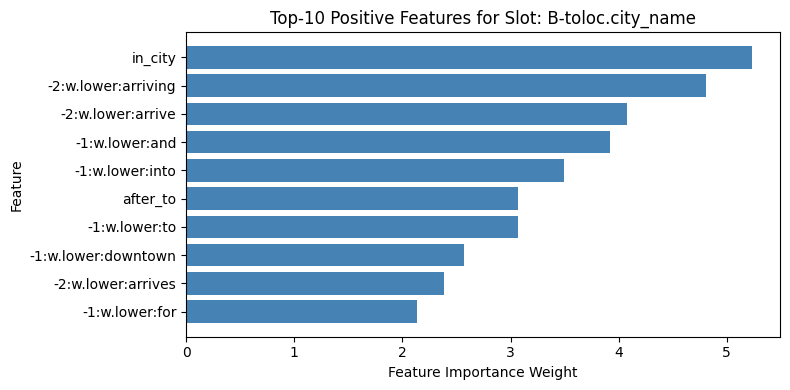

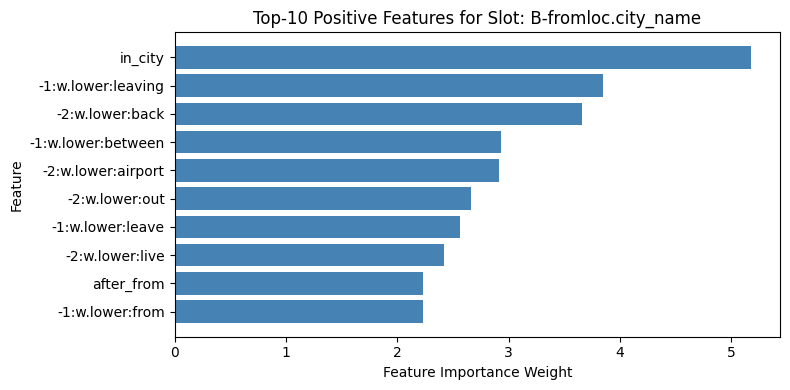

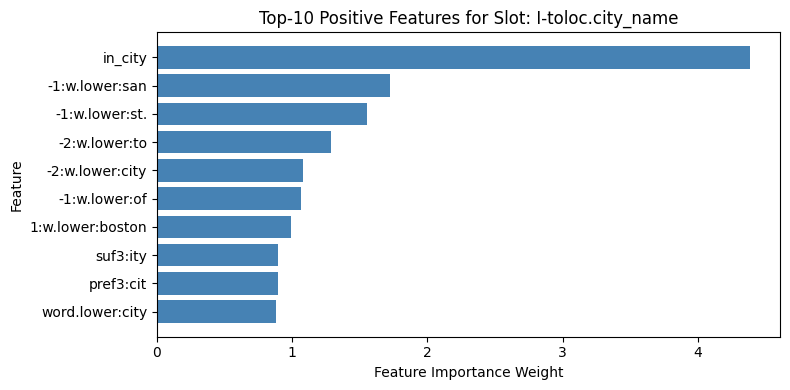

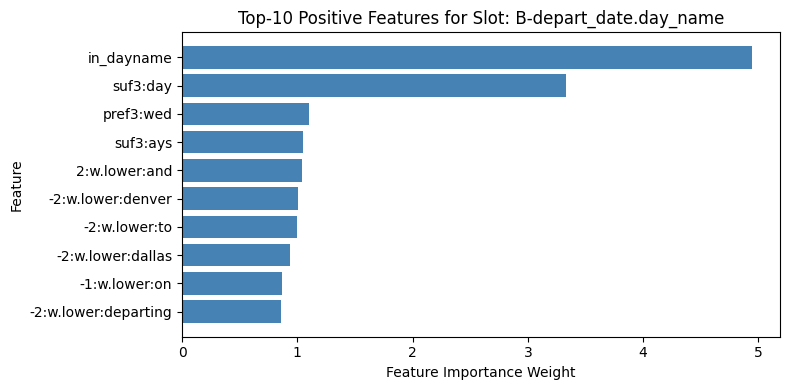

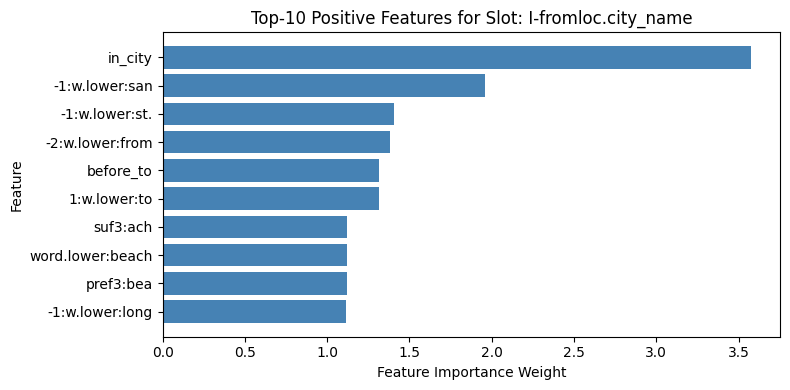

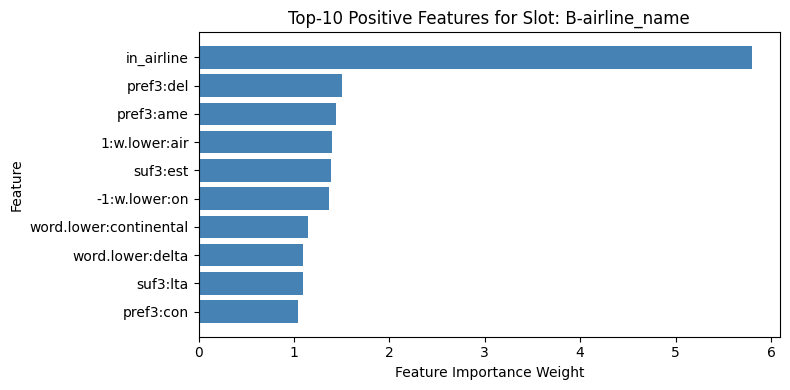

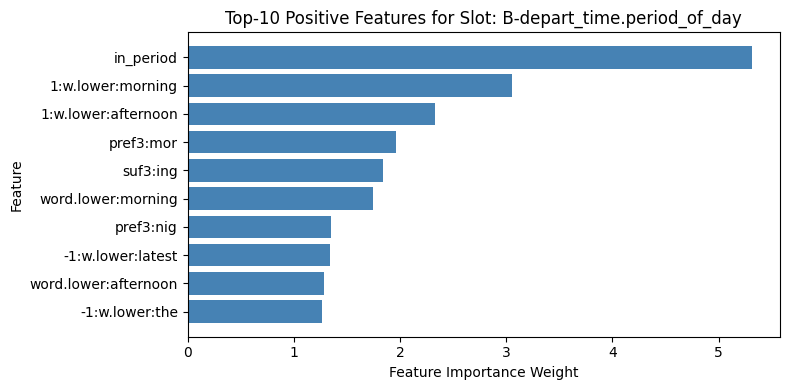

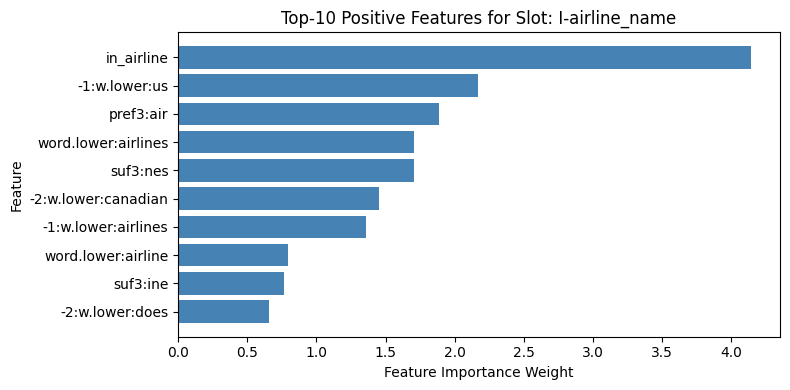

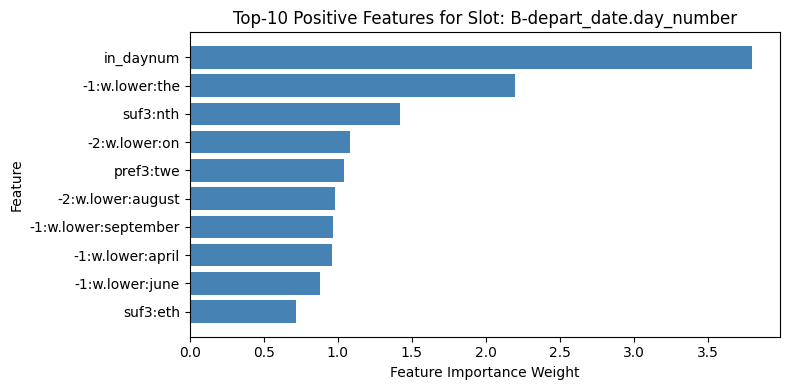

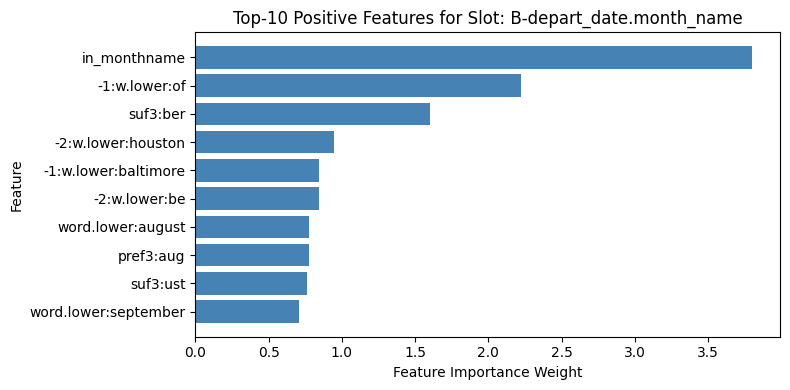

In [31]:
# find the top10 most frequent slot types
slot_counter = Counter([slot for _, slots, _ in train_split for slot in slots])
slot_counter.pop("O", None)
slot_counter.pop("<PAD>", None)
top10_slots = [lab for lab, _ in slot_counter.most_common(10)]

# extract top10 highest-weight features for each slot
rows = []
for slot in top10_slots:
    # collect all feature weights
    feats_for_slot = [(feat, w) for (feat, lab), w in crf.state_features_.items() if lab == slot]
    # sort by descending weight and take top 10
    top_feats = sorted(feats_for_slot, key=itemgetter(1), reverse=True)[:10]
    for rank, (feat, w) in enumerate(top_feats, 1):
        rows.append({
            "slot": slot,
            "rank": rank,
            "feature": feat,
            "weight": float(w)
        })

# convert to a DataFrame
df_top10 = pd.DataFrame(rows).sort_values(["slot", "rank"]).reset_index(drop=True)

# visualization
# create bar chart for each slot
for slot in top10_slots:
    df_s = df_top10[df_top10["slot"] == slot]
    plt.figure(figsize=(8,4))
    plt.barh(df_s["feature"], df_s["weight"], color="steelblue")
    plt.title(f"Top-10 Positive Features for Slot: {slot}")
    plt.xlabel("Feature Importance Weight")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


* The next part focuses on identifying key features for intent detection from logistic regression after hyperparameters tuning. The visualization presents the top 20 most important features according to the permutation importance analysis. The strongest signals are fare-related terms, which dominate pricing-related queries and clearly distinguish the “atis_airfare” intent. The next several features are keyword groups generated from the word cloud, indicating that these terms are strongly correlated with their respective intents. In addition, other categories such as time, date, and question-related words also play an important role, confirming the effectiveness of the designed TF-IDF and keyword-based features in identifying user intent.

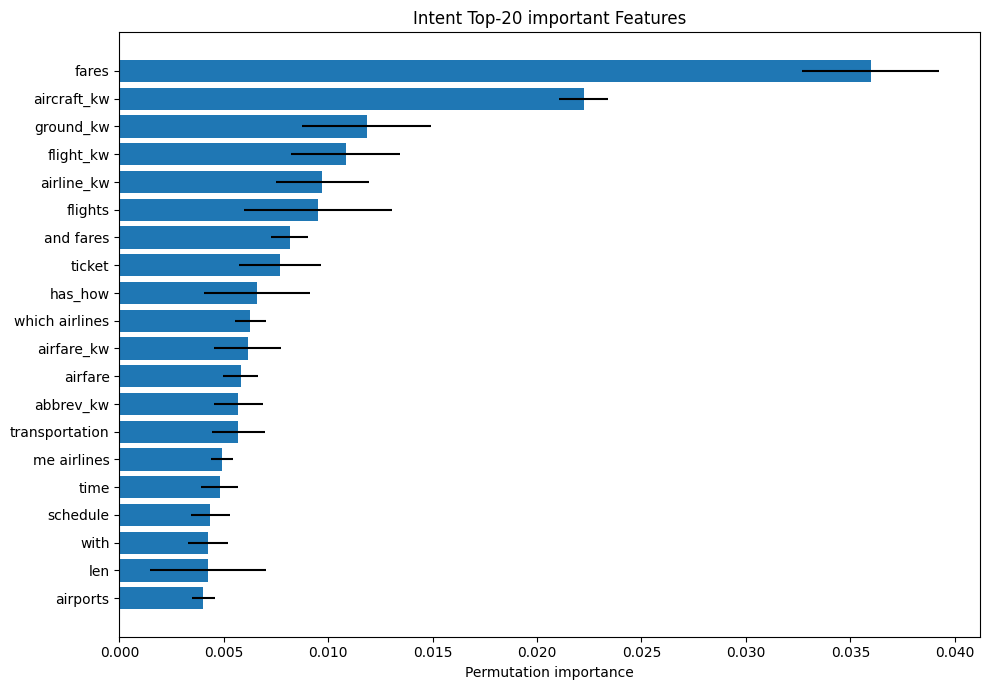

In [39]:
Xva_dense = Xva_all.toarray()
y_val_dense = np.asarray(y_val_int)

# get feature names
tf_names = tfidf.get_feature_names_out().tolist()
aux_names = list(kw.keys()) + [
    'len','caps','digits','has_what','has_which','has_how','has_from','has_to','has_between'
]
feat_names = tf_names + aux_names
assert len(feat_names) == Xva_dense.shape[1], f"feat_names={len(feat_names)} vs Xva={Xva_dense.shape[1]}"


# modelling
lr = best_lr

# permutation importance
result = permutation_importance(
    lr, Xva_dense , y_val_int,
    scoring='accuracy',
    n_repeats=10,
    random_state=123,
    n_jobs=-1
)

imp_mean = result.importances_mean
imp_std  = result.importances_std

# visualization
topk = 20
idx = np.argsort(imp_mean)[-topk:][::-1]
df_imp = pd.DataFrame({
    "feature": [feat_names[i] for i in idx],
    "importance": imp_mean[idx],
    "std": imp_std[idx],
})

plt.figure(figsize=(10,7))
plt.barh(range(topk), df_imp["importance"][::-1], xerr=df_imp["std"][::-1])
plt.yticks(range(topk), df_imp["feature"][::-1])
plt.xlabel("Permutation importance")
plt.title("Intent Top-20 important Features")
plt.tight_layout()
plt.show()

### 3.4.2 Model comparison

**Slot Filling**
* Traditional Model: Conditional Random Field

Advantages:

1. Highly interpretable – allows users to manually design and customize linguistic, lexical, and positional features.

2. Feature transparency – learned feature weights clearly indicate which lexical or contextual cues contribute most to specific slot types.

Disadvantages:

1. Heavy dependence on manual feature engineering and predefined vocabularies limits adaptability to unseen words or new domains.

2. Limited contextual learning – cannot automatically capture semantic dependencies beyond the defined feature window.

* Modern Model: Bidirectional Long Short-Term Memory with CRF (BiLSTM-CRF)

Advantages:

1. No manual feature design required – the model learns contextual representations directly from raw text sequences.

2. Improved performance – achieves higher F1 scores, especially for rare or context-dependent slots, by modeling long-range dependencies.

Disadvantages:

1. Higher computational cost – training requires more time and resources compared to CRF.

2. Low interpretability – it is difficult to trace which specific contextual cues drive predictions.

3. Data dependency – performance may degrade when trained on small or homogeneous datasets.

**Intent Detection**
* Traditional Model: Logistic Regression (TF-IDF + Keyword Features)

Advantages:

1. Highly interpretable – model weights clearly indicate which words or keyword groups most influence intent classification.

2. Efficient and lightweight – fast to train and evaluate, making it a strong and transparent baseline.

3. Effective for lexically distinct intents such as “fare”, “flight”, and “airline”.

Disadvantages:

1. Lacks contextual understanding – cannot effectively capture meaning beyond individual words.

2. Feature engineering dependence – performance relies heavily on manually curated keywords and TF-IDF preprocessing.

* Modern Model: BERT Fine-tuning

Advantages:

1. Deep contextual understanding – the self-attention mechanism captures rich semantic and syntactic relationships between tokens.

2. Robust generalization – effectively handles synonyms, paraphrases, and long-range dependencies without manual feature design.

Disadvantages:

1. Computationally intensive – fine-tuning requires significant GPU resources and careful hyperparameter tuning.

2. Low interpretability – difficult to explain which tokens or layers contribute to each prediction.

## 3.5 Apply CRF + BERT to test set for better result

We select CRF for slot filling and BERT for intent detection. based on its F1 score and model stability after hyperparameters tuning.

### 3.5.1 Read the test file

In [ ]:
test_path = "/content/drive/MyDrive/data/test.txt"
with open(test_path, "r", encoding="utf-8") as f:
    test_utts = [ln.strip() for ln in f if ln.strip()]

# tokenize by simple whitespace
test_tokens = [utt.split() for utt in test_utts]

print(f"Loaded {len(test_utts)} test utterances.")

Loaded 662 test utterances.


### 3.5.2 Apply BERT to get the prediction of intent

In [ ]:
# join train+val for final fit
final_texts = [" ".join(w) for w,_,_ in (train_split + val_split)]
final_labels = np.array([loader.intent_vocab[it] for _,_,it in (train_split + val_split)])

tok_int = BertTokenizer.from_pretrained('/content/bert-base-uncased')
model_int = BertForSequenceClassification.from_pretrained('/content/bert-base-uncased',num_labels=len(loader.intent_vocab))

class IntentDS(torch.utils.data.Dataset):
    def __init__(self, texts, labels=None):
        enc = tok_int(texts, padding=True, truncation=True, return_tensors="pt")
        self.enc, self.labels = enc, (None if labels is None else torch.tensor(labels, dtype=torch.long))
    def __len__(self): return self.enc["input_ids"].shape[0]
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        if self.labels is not None: item["labels"] = self.labels[i]
        return item

trainval_ds = IntentDS(final_texts, final_labels)
test_intent_ds = IntentDS(test_utts, None)

# tuned hyperparameters
args = TrainingArguments(
    output_dir="./intent_bert_best",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_ratio=0.0,
    eval_strategy="no",
    save_strategy="no",
    report_to=[],
    seed=123,
    fp16=torch.cuda.is_available(),
)

trainer_int = Trainer(model=model_int, args=args, train_dataset=trainval_ds)
trainer_int.train()

# inference on test
pred_int = trainer_int.predict(test_intent_ds)
y_pred_int = np.argmax(pred_int.predictions, axis=-1)
id2intent = {v:k for k,v in loader.intent_vocab.items()}
intent_pred_names = [id2intent[i] for i in y_pred_int]


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Step,Training Loss
500,0.308000


### 3.5.3 Apply CRF to get the prediction of slot

In [35]:
# tuned hyperparameters
final_crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1= 0.001,
    c2= 0.01,
    max_iterations=200,
    all_possible_transitions=True
)
final_crf.fit(X_train, y_train)
# predict on test dataset
X_test = [sent2features(w) for w in test_tokens]
slot_pred_seqs = final_crf.predict(X_test)

### 3.5.4 Get the output of the prediction

In [ ]:
# build the same format as training data
lines = []
for toks, tags, intent in zip(test_tokens, slot_pred_seqs, intent_pred_names):
    tok_tag_pairs = [f"{t}:{y}" for t, y in zip(toks, tags)]
    line = f"{' '.join(tok_tag_pairs)} <=> {intent}"
    lines.append(line)

out_path = "slot_prediction.txt"
with open(out_path, "w", encoding="utf-8") as f:
    for ln in lines:
        f.write(ln + "\n")

print(f"Saved predictions in {out_path}")

Saved predictions in A2_Task_2_pred.txt
